In [40]:
# 1. Importera bibliotek
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 2. Läs in data
data_dir = "db_29_3_text"
occ = pd.read_csv(os.path.join(data_dir, "Occupation Data.txt"), sep='\t', encoding='utf-8')
skills = pd.read_csv(os.path.join(data_dir, "Skills.txt"), sep='\t', encoding='utf-8')
rel = pd.read_csv(os.path.join(data_dir, "Related Occupations.txt"), sep='\t', encoding='utf-8')


In [2]:
# 3. Skapa (yrke x skill)-matriser för IM och LV
skills_lv = skills[skills['Scale ID'] == 'LV']
skills_im = skills[skills['Scale ID'] == 'IM']

# Pivotera till yrke x skill
lv_matrix = skills_lv.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
im_matrix = skills_im.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')

# Säkerställ samma yrkesordning för båda matriser
lv_matrix = lv_matrix.reindex(im_matrix.index)


In [3]:
# 4. PCA på IM för att få (PC1, PC2)
pca = PCA(n_components=2)
im_filled = im_matrix.fillna(0)
im_coords = pca.fit_transform(im_filled.values)


In [4]:
# 5. Beräkna xi (vinkel) och chi (radie, viktad LV)
xi = np.arctan2(im_coords[:, 1], im_coords[:, 0]) % (2 * np.pi)

# Viktat LV per yrke (IM som vikt)
lv_weighted = (lv_matrix * im_matrix).sum(axis=1) / im_matrix.sum(axis=1)
chi = (lv_weighted - lv_weighted.min()) / (lv_weighted.max() - lv_weighted.min())


In [37]:
# 6. Bygg slutlig DataFrame för occupation space
occ_titles = occ.set_index('O*NET-SOC Code').reindex(im_matrix.index)['Title']

final_df = pd.DataFrame({
    'onet_code': im_matrix.index,
    'title': occ_titles.values,
    'im_pc1': im_coords[:, 0],
    'im_pc2': im_coords[:, 1],
    'xi': xi,
    'chi': chi.values,
})

# Omvandla till kartesiska koordinater
x = final_df['chi'] * np.cos(final_df['xi'])
y = final_df['chi'] * np.sin(final_df['xi'])

# Centrera utifrån medelvinkel för de punkter med lägst chi:
n = 50  # eller önskat antal
low_chi = final_df.nsmallest(n, 'chi')
mean_x = (low_chi['chi'] * np.cos(low_chi['xi'])).mean()
mean_y = (low_chi['chi'] * np.sin(low_chi['xi'])).mean()
low_chi_angle = np.arctan2(mean_y, mean_x) % (2 * np.pi)
final_df['xi_rot'] = (final_df['xi'] - low_chi_angle) % (2 * np.pi)



In [35]:
import matplotlib.pyplot as plt
import numpy as np

def plot_occupation_space_centered(
    df,
    chi_col='chi',
    xi_col='xi_rot',    # <- OBS: nu default
    color_col=None,
    annotate_n=8,
    figsize=(9,9),
    title=None,
    alpha=0.7,
    cmap='tab20'
):
    """
    Plotta occupation space i polära koordinater. Ingen rotation sker här!
    xi_col: ska redan vara roterad.
    """
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection':'polar'})

    # Plotta punkterna
    if color_col and color_col in df.columns:
        categories = df[color_col].astype('category').cat.codes
        sc = ax.scatter(df[xi_col], df[chi_col], c=categories, cmap=cmap, alpha=alpha, s=20)
        handles, labels = sc.legend_elements()
        legend_labels = df[color_col].astype('category').cat.categories
        ax.legend(handles, legend_labels, title=color_col, fontsize=8, loc='best')
    else:
        ax.scatter(df[xi_col], df[chi_col], color='blue', alpha=alpha, s=20)

    # Annotera titlar längst ut på cirkeln
    n = annotate_n
    if n > 0 and 'title' in df.columns:
        idx_max = df[chi_col].nlargest(n).index
        idx_min = df[chi_col].nsmallest(n).index
        idxs = pd.Index(idx_max.tolist() + idx_min.tolist()).unique()
        annots = df.loc[idxs]

        chi_label = 1.06  # Radie utanför cirkeln
        for _, row in annots.iterrows():
            angle = row[xi_col]
            ax.annotate(
                row['title'],
                xy=(angle, row[chi_col]),        # punktens (vinkel, radie)
                xytext=(angle, chi_label),       # etikettens (vinkel, radie)
                textcoords='data',
                ha='center', va='center',
                fontsize=8,
                rotation=0,
                arrowprops=dict(arrowstyle='-', lw=0.8, color='gray', alpha=0.8)
            )

    ax.set_rlabel_position(0)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig, ax


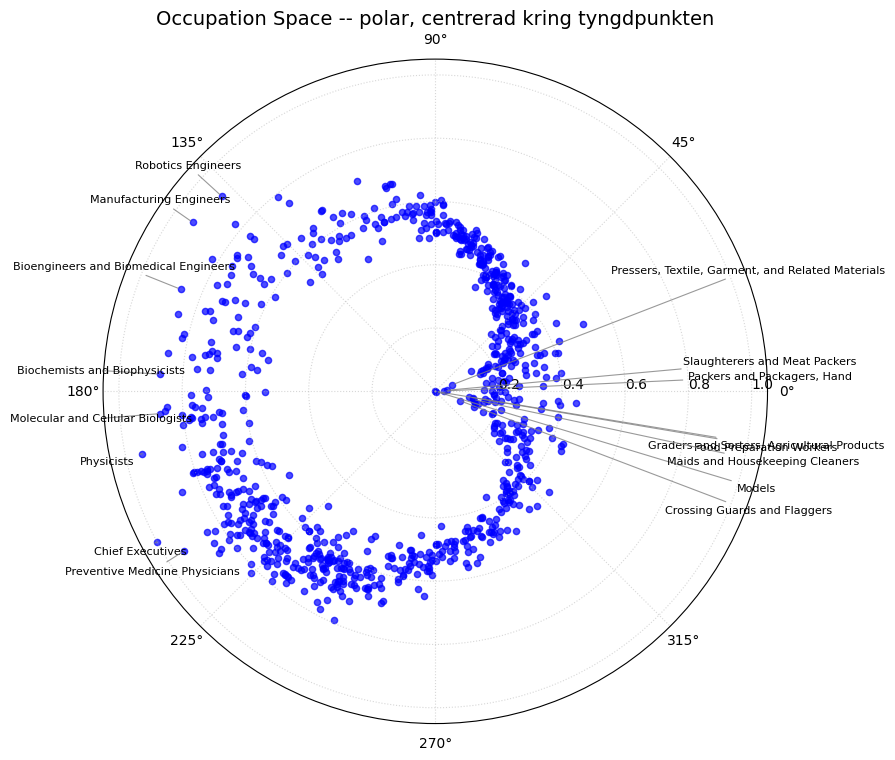

(<Figure size 900x900 with 1 Axes>,
 <PolarAxes: title={'center': 'Occupation Space -- polar, centrerad kring tyngdpunkten'}>)

In [38]:
# 8. Visualisera occupation space!
plot_occupation_space_centered(
    final_df,
    chi_col='chi',
    xi_col='xi_rot',
    color_col=None,     # eller t.ex. 'cluster' om sådan finns
    annotate_n=8,
    title='Occupation Space -- polar, centrerad kring tyngdpunkten'
)


In [42]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# 1. Beräkna kartesiska koordinater för occupation space
final_df['x'] = final_df['chi'] * np.cos(final_df['xi_rot'])
final_df['y'] = final_df['chi'] * np.sin(final_df['xi_rot'])

# 2. Bygg lookup-tabell från O*NET-kod till (x, y)
code2xy = final_df.set_index('onet_code')[['x', 'y']].to_dict('index')

# 3. Räkna ut occupation space-avstånd för varje rad i rel
def occs_distance(row):
    code1 = row['O*NET-SOC Code']
    code2 = row['Related O*NET-SOC Code']
    xy1 = code2xy.get(code1)
    xy2 = code2xy.get(code2)
    if xy1 is not None and xy2 is not None:
        return np.sqrt((xy1['x'] - xy2['x'])**2 + (xy1['y'] - xy2['y'])**2)
    else:
        return np.nan

rel['ocs_distance'] = rel.apply(occs_distance, axis=1)

# 4. Bygg närhetslista (rank) för alla yrken i occupation space
coords = final_df[['x', 'y']].values
codes = final_df['onet_code'].values
dist_matrix = cdist(coords, coords)  # Avståndsmatris

# Lista: för varje yrke, vilka är närmast?
nearest_ranks = {}
for i, code in enumerate(codes):
    dists = dist_matrix[i]
    sorted_indices = np.argsort(dists)
    sorted_codes = codes[sorted_indices]
    nearest_ranks[code] = {other_code: rank for rank, other_code in enumerate(sorted_codes)}

# 5. För varje rad i rel: rank för den relaterade yrkeskoden
rel['ocs_rank'] = rel.apply(
    lambda row: nearest_ranks.get(row['O*NET-SOC Code'], {}).get(row['Related O*NET-SOC Code'], np.nan),
    axis=1
)

# 6. Nu kan du t.ex. analysera:
print("Exempel på rel-data med avstånd och rank:")
display(rel.head(20))


Exempel på rel-data med avstånd och rank:


,O*NET-SOC Code,Related O*NET-SOC Code,Relatedness Tier,Index,ocs_distance,ocs_rank
0,11-1011.00,11-1021.00,Primary-Short,1,0.375073,103.0
1,11-1011.00,11-2032.00,Primary-Short,2,NaN,NaN
2,11-1011.00,11-9151.00,Primary-Short,3,0.255185,24.0
3,11-1011.00,11-3031.01,Primary-Short,4,0.382668,110.0
4,11-1011.00,11-9199.02,Primary-Short,5,0.635912,269.0
5,11-1011.00,11-9033.00,Primary-Long,6,0.428130,147.0
6,11-1011.00,11-3121.00,Primary-Long,7,0.409422,130.0
7,11-1011.00,11-1031.00,Primary-Long,8,NaN,NaN
8,11-1011.00,11-3031.00,Primary-Long,9,0.529580,199.0
9,11-1011.00,11-1011.03,Primary-Long,10,0.302404,52.0


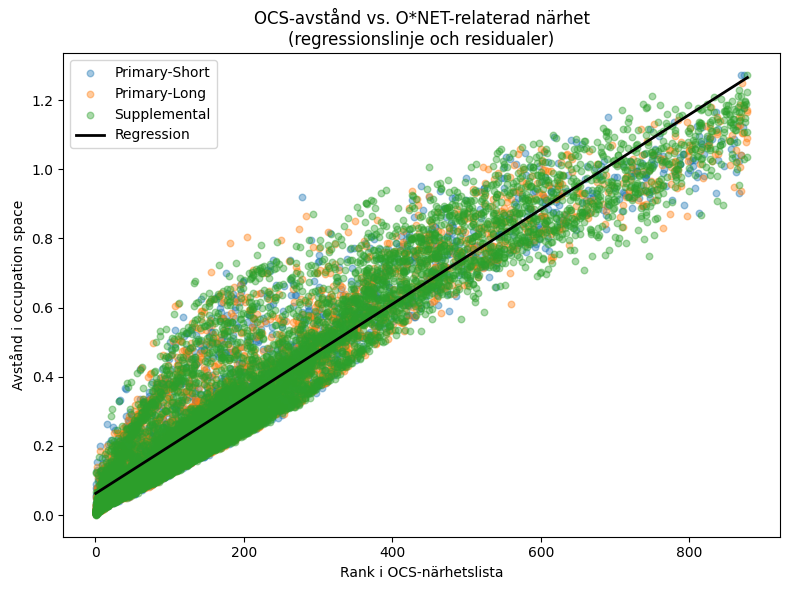

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Endast icke-NaN
mask = rel['ocs_distance'].notna() & rel['ocs_rank'].notna()
df_plot = rel.loc[mask].copy()

plt.figure(figsize=(8,6))
tiers = df_plot['Relatedness Tier'].unique()
colors = sns.color_palette('tab10', n_colors=len(tiers))

# Färglägg varje Relatedness Tier
for i, tier in enumerate(tiers):
    sel = df_plot['Relatedness Tier'] == tier
    plt.scatter(df_plot.loc[sel, 'ocs_rank'], df_plot.loc[sel, 'ocs_distance'],
                color=colors[i], alpha=0.4, label=tier, s=22)

# Lägg till regressionslinje
from sklearn.linear_model import LinearRegression

X = df_plot['ocs_rank'].values.reshape(-1,1)
y = df_plot['ocs_distance'].values
reg = LinearRegression().fit(X, y)
xfit = np.linspace(X.min(), X.max(), 200)
yfit = reg.predict(xfit.reshape(-1,1))
plt.plot(xfit, yfit, color='black', lw=2, label='Regression')

# Residualer som vertikala linjer
show_residuals = False
if show_residuals:
    sample = df_plot.sample(min(400, len(df_plot)), random_state=1)  # för att plotten inte ska bli för rörig
    ypred = reg.predict(sample['ocs_rank'].values.reshape(-1,1))
    for xi, yi, yhat in zip(sample['ocs_rank'], sample['ocs_distance'], ypred):
        plt.plot([xi, xi], [yi, yhat], color='gray', alpha=0.15, lw=1)

plt.xlabel('Rank i OCS-närhetslista')
plt.ylabel('Avstånd i occupation space')
plt.title('OCS-avstånd vs. O*NET-relaterad närhet\n(regressionslinje och residualer)')
plt.legend()
plt.tight_layout()
plt.show()


In [44]:
from scipy.stats import spearmanr, pearsonr

# Ta bort NaN
mask = rel['ocs_distance'].notna() & rel['ocs_rank'].notna()
x = rel.loc[mask, 'ocs_rank']
y = rel.loc[mask, 'ocs_distance']

print('Spearman rangkorrelation:', spearmanr(x, y))
print('Pearson korrelation:', pearsonr(x, y))


Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.9403020848480903), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.9497404631101992), pvalue=np.float64(0.0))
